# loc_lambda=0.1, alpha=0.5000

## 1. Paths & Training Hyperparameters

In [1]:
import os, sys, math, time, random, itertools
from typing import Tuple, List, Dict
import timm

IMG_ROOT = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images"
TRAIN_CSV = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_train_images.csv"
TEST_CSV  = r"C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_test_images.csv"
MASK_ROOT = IMG_ROOT.replace("png_images", "png_masks")  

OUT_DIR   = "./ConvLoc(Sampler)_Output"

IMG_SIZE  = 576  
EPOCHS    = 120       
BATCH     = 4         
LR        = 2e-4
SEED      = 42
VAL_RATIO = 0.20       
SAMPLER   = "on"  

print("IMG_ROOT:", IMG_ROOT)
print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV:", TEST_CSV)
print("OUT_DIR:", OUT_DIR)
print("EPOCHS/BATCH/LR:", EPOCHS, BATCH, LR)
print("VAL_RATIO/SAMPLER:", VAL_RATIO, SAMPLER)

IMG_ROOT: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images
TRAIN_CSV: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_train_images.csv
TEST_CSV: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\stage_1_test_images.csv
OUT_DIR: ./ConvLoc(Sampler)_Output
EPOCHS/BATCH/LR: 120 4 0.0002
VAL_RATIO/SAMPLER: 0.2 on


## 2. Imports & Device

In [2]:
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"figure.dpi": 110})

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED)
print(f"Using device: {device} | AMP: {'on' if device.type=='cuda' else 'off'}")

Using device: cuda | AMP: on


## 3. Read CSVs & Quick Preview

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head(8))
display(test_df.head(8))

print("Train shape:", train_df.shape, "Columns:", list(train_df.columns))
print("Test  shape:", test_df.shape, "Columns:", list(test_df.columns))

print("Train label distribution:", train_df["has_pneumo"].value_counts().to_dict())
print("Test  label distribution:", test_df["has_pneumo"].value_counts().to_dict())

,new_filename,ImageId,has_pneumo
0,0_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.5597.151787518...,0
1,1_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.12515.15178752...,0
2,2_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.4904.151787518...,1
3,3_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,1
4,4_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.1314.151787516...,1
5,5_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.11364.15178752...,0
6,6_train_0_.png,1.2.276.0.7230010.3.1.4.8323329.4541.151787518...,0
7,7_train_1_.png,1.2.276.0.7230010.3.1.4.8323329.4440.151787518...,1


,new_filename,ImageId,has_pneumo
0,0_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5797.151787519...,1
1,1_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5798.151787519...,0
2,2_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5799.151787519...,0
3,3_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.580.1517875163...,0
4,4_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5800.151787519...,0
5,5_test_0_.png,1.2.276.0.7230010.3.1.4.8323329.5801.151787519...,0
6,6_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5802.151787519...,1
7,7_test_1_.png,1.2.276.0.7230010.3.1.4.8323329.5803.151787519...,1


Train shape: (10675, 3) Columns: ['new_filename', 'ImageId', 'has_pneumo']
Test  shape: (1372, 3) Columns: ['new_filename', 'ImageId', 'has_pneumo']
Train label distribution: {0: 8296, 1: 2379}
Test  label distribution: {0: 1082, 1: 290}


## 4. Full-path Resolution & Dataset 

In [4]:
def resolve_full_paths(df: pd.DataFrame, img_root: str) -> pd.DataFrame:
    df = df.copy()
    def _resolve(row):
        name = str(row["new_filename"])
        name_png = name if name.lower().endswith(".png") else f"{name}.png"
        p1 = os.path.join(img_root, name_png)
        if os.path.exists(p1):
            return p1
        # fallback: ImageId.png
        alt = os.path.join(img_root, f"{row['ImageId']}.png")
        return alt if os.path.exists(alt) else p1
    df["full_path"] = df.apply(_resolve, axis=1)
    return df

train_df = resolve_full_paths(train_df, IMG_ROOT)
test_df  = resolve_full_paths(test_df,  IMG_ROOT)

missing_train = (~train_df["full_path"].apply(os.path.exists)).sum()
missing_test  = (~test_df["full_path"].apply(os.path.exists)).sum()
print(f"Missing files — Train: {missing_train} | Test: {missing_test}")

class PandasImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("L")
        if self.transform: img = self.transform(img)
        y = int(row["has_pneumo"])
        return img, y
    
class JointImageMaskTransform:
    def __init__(self, out_size=IMG_SIZE):
        self.out_size = out_size

    def __call__(self, img, mask):
        # Resize + RandomResizedCrop + RandomHorizontalFlip + ToTensor + Normalize
        resize_to = int(self.out_size * 1.1)
        img  = TF.resize(img,  (resize_to, resize_to), interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (resize_to, resize_to), interpolation=InterpolationMode.NEAREST)

        i, j, h, w = torchvision.transforms.RandomResizedCrop.get_params(
            img,
            scale=(0.8, 1.0),
            ratio=(0.9, 1.1)
        )
        img  = TF.resized_crop(img,  i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.BILINEAR)
        mask = TF.resized_crop(mask, i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        if random.random() < 0.5:
            angle = random.uniform(-7, 7)
            img  = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            b_factor = 1.0 + random.uniform(-0.15, 0.15)
            c_factor = 1.0 + random.uniform(-0.15, 0.15)
            img = TF.adjust_brightness(img, b_factor)
            img = TF.adjust_contrast(img, c_factor)

        img  = TF.to_tensor(img)               # [1,H,W], [0,1]
        img  = TF.normalize(img, [0.5], [0.25])

        mask = TF.to_tensor(mask)              # [1,H,W], [0,1]
        mask = (mask > 0.5).float()            # Binarize

        return img, mask

class PandasImageMaskDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mask_root: str, joint_transform: JointImageMaskTransform):
        self.df = df.reset_index(drop=True)
        self.mask_root = mask_root
        self.joint_transform = joint_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Images come from full_path
        img_path = row["full_path"]
        img = Image.open(img_path).convert("L")

        # Masks come from mask_root + basename
        basename = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_root, basename)

        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found for {img_path} -> {mask_path}")

        mask = Image.open(mask_path).convert("L")

        img, mask = self.joint_transform(img, mask)

        y = float(row["has_pneumo"])
        return img, y, mask

Missing files — Train: 0 | Test: 0


In [5]:
os.makedirs(OUT_DIR, exist_ok=True)
EDA_DIR = os.path.join(OUT_DIR, "eda"); os.makedirs(EDA_DIR, exist_ok=True)

def eda_class_distribution(df: pd.DataFrame, label_col: str, out_path: str, title: str):
    counts = df[label_col].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    xs = [str(int(x)) for x in counts.index.tolist()]
    ys = counts.values.astype(int)
    plt.bar(xs, ys)
    for i, y in enumerate(ys):
        plt.text(i, y, str(y), ha="center", va="bottom", fontsize=9)
    plt.title(f"Class Distribution — {title}")
    plt.xlabel("Label"); plt.ylabel("Count")
    plt.tight_layout(); plt.savefig(out_path); plt.show()

def eda_missing_files(df: pd.DataFrame, out_txt: str, title: str):
    missing_mask = ~df["full_path"].apply(os.path.exists)
    total = len(df); missing = missing_mask.sum()
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write(f"Total rows: {total}\nMissing files: {missing}\n")
        if missing:
            f.write("First 50 missing examples:\n")
            f.write("\n".join(df.loc[missing_mask, "full_path"].head(50).tolist()))
    print(f"[{title}] Missing: {missing}/{total} — saved to {out_txt}")

def eda_sample_grid(df: pd.DataFrame, out_path: str, title: str, n_per_class: int = 8, size: int = 128):
    labels = sorted(df["has_pneumo"].unique().tolist())
    panels = []
    for lab in labels:
        subset = df[df["has_pneumo"] == lab]
        sample = subset.sample(min(n_per_class, len(subset)), random_state=0)
        panels.append(sample)

    cols = n_per_class; rows = len(labels)
    plt.figure(figsize=(cols*2, rows*2))
    idx = 1
    for r, panel in enumerate(panels):
        for _, row in panel.iterrows():
            fp = row["full_path"]
            plt.subplot(rows, cols, idx)
            try:
                img = Image.open(fp).convert("L").resize((size,size))
                plt.imshow(img, cmap="gray"); plt.axis("off")
            except Exception:
                plt.text(0.5,0.5,"missing",ha="center",va="center"); plt.axis("off")
            idx += 1
    plt.suptitle(f"Sample Grid — {title}", y=0.98)
    plt.tight_layout(); plt.savefig(out_path); plt.show()

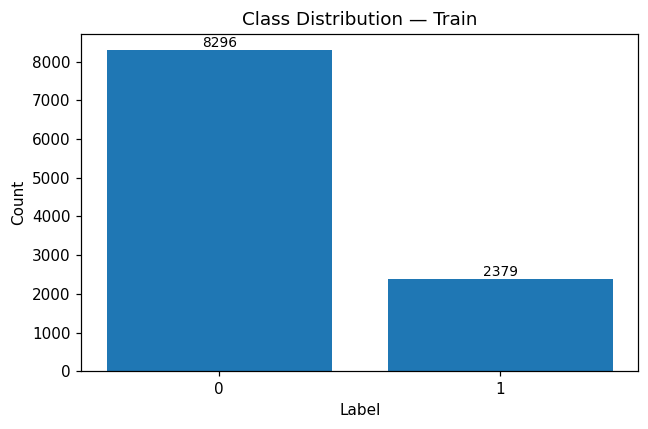

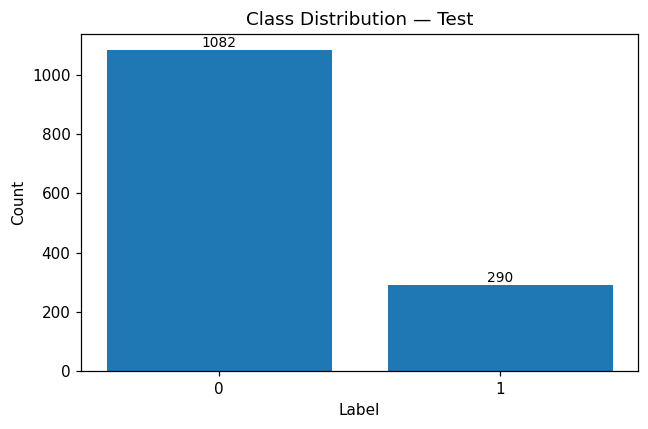

[Train] Missing: 0/10675 — saved to ./ConvLoc(Sampler)_Output\eda\missing_train.txt
[Test] Missing: 0/1372 — saved to ./ConvLoc(Sampler)_Output\eda\missing_test.txt


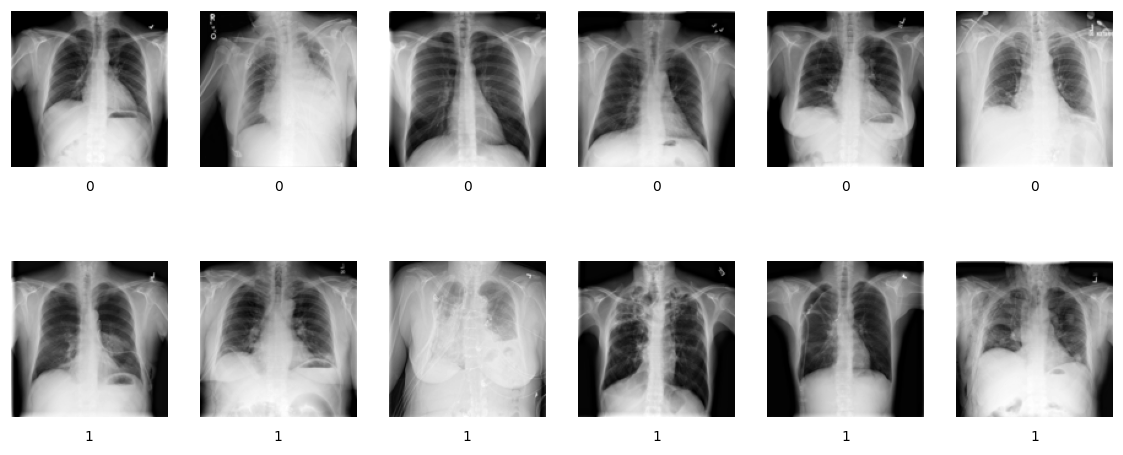

In [6]:
from pathlib import Path

eda_class_distribution(train_df, "has_pneumo", os.path.join(EDA_DIR, "class_dist_train.png"), "Train")
eda_class_distribution(test_df,  "has_pneumo", os.path.join(EDA_DIR, "class_dist_test.png"),  "Test")

eda_missing_files(train_df, os.path.join(EDA_DIR, "missing_train.txt"), "Train")
eda_missing_files(test_df,  os.path.join(EDA_DIR, "missing_test.txt"),  "Test")

def eda_sample_grid(df, out_path, split_name, n_per_class=6, size=128):
    label_col = "has_pneumo"
    path_col = "full_path" if "full_path" in df.columns else "filepath"

    classes = sorted(df[label_col].dropna().unique().tolist())
    nrows, ncols = len(classes), n_per_class
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2.2, nrows*2.4))
    if nrows == 1:
        axes = np.array([axes])

    for r, c in enumerate(classes):
        sub = df[df[label_col] == c]
        sampled = sub.sample(n=min(n_per_class, len(sub)), random_state=42) if len(sub) > 0 else sub
        sampled = sampled.reset_index(drop=True)

        for i in range(ncols):
            ax = axes[r, i]
            ax.set_axis_off()

            if i < len(sampled):
                row = sampled.iloc[i]
                img_path = str(Path(row[path_col]))
                try:
                    im = Image.open(img_path).convert("L")
                    if size:
                        im = im.resize((size, size))
                    ax.imshow(im, cmap="gray")
                except Exception:
                    ax.imshow(np.zeros((size, size)), cmap="gray")

                ax.text(0.5, -0.08, str(row[label_col]),
                        transform=ax.transAxes, ha="center", va="top", fontsize=9)
            else:
                ax.imshow(np.zeros((size, size)), cmap="gray")

    plt.subplots_adjust(hspace=0.6, wspace=0.05)
    plt.show()
    Path(os.path.dirname(out_path)).mkdir(parents=True, exist_ok=True)
    # fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

eda_sample_grid(train_df, os.path.join(EDA_DIR, "sample_grid_train.png"), "Train", n_per_class=6, size=128)

In [7]:
# Combine train + test for splitting
full_df = pd.concat([train_df, test_df], ignore_index=True)

print("Original full size:", len(full_df))
print("Label distribution (full):", full_df["has_pneumo"].value_counts().to_dict())

from sklearn.model_selection import train_test_split

# 20% of the data for val + test
train_tmp, temp_df = train_test_split(
    full_df,
    test_size=0.2,               
    stratify=full_df["has_pneumo"],
    random_state=SEED,
)

# 10% val, 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,              
    stratify=temp_df["has_pneumo"],
    random_state=SEED,
)

tr_df = train_tmp.reset_index(drop=True)

print("8:1:1 split sizes ->",
      "Train:", len(tr_df),
      "Val:",   len(val_df),
      "Test:",  len(test_df))

print("Train label dist (before oversampling):",
      tr_df["has_pneumo"].value_counts().to_dict())
print("Val   label dist:",
      val_df["has_pneumo"].value_counts().to_dict())
print("Test  label dist:",
      test_df["has_pneumo"].value_counts().to_dict())

if SAMPLER == "off":
    # Oversampling minority class in training set
    pos_df = tr_df[tr_df["has_pneumo"] == 1]
    neg_df = tr_df[tr_df["has_pneumo"] == 0]

    n_pos = len(pos_df)
    n_neg = len(neg_df)
    target_pos = n_neg               

    factor    = target_pos // n_pos
    remainder = target_pos % n_pos

    pos_oversampled = pd.concat(
        [pos_df] * factor + [pos_df.sample(remainder, replace=True, random_state=SEED)],
        ignore_index=True
    )

    tr_df_bal = pd.concat([neg_df, pos_oversampled], ignore_index=True)
    tr_df_bal = tr_df_bal.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    print("After oversampling Train label dist:",
          tr_df_bal["has_pneumo"].value_counts().to_dict())

    tr_df = tr_df_bal
else:
    print("SAMPLER is ON -> skip dataframe oversampling, use original imbalanced train set.")


Original full size: 12047
Label distribution (full): {0: 9378, 1: 2669}
8:1:1 split sizes -> Train: 9637 Val: 1205 Test: 1205
Train label dist (before oversampling): {0: 7502, 1: 2135}
Val   label dist: {0: 938, 1: 267}
Test  label dist: {0: 938, 1: 267}
SAMPLER is ON -> skip dataframe oversampling, use original imbalanced train set.


In [8]:
# Transforms
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.25]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.25]),
])

# Joint transforms for image + mask (training set)
joint_train_tfms = JointImageMaskTransform(out_size=IMG_SIZE)

# Datasets
ds_train = PandasImageMaskDataset(tr_df, mask_root=MASK_ROOT, joint_transform=joint_train_tfms)
ds_val   = PandasImageDataset(val_df, transform=eval_tfms)
ds_test  = PandasImageDataset(test_df, transform=eval_tfms)

def make_weights_for_balancing(df: pd.DataFrame) -> np.ndarray:
    counts = df["has_pneumo"].value_counts().to_dict()
    return df["has_pneumo"].map(lambda y: 1.0 / counts[int(y)]).values.astype(np.float32)


if SAMPLER == "on":
    weights = make_weights_for_balancing(tr_df)
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
    shuffle = False
else:
    sampler = None; shuffle = True

# DataLoaders
dl_train = DataLoader(ds_train, batch_size=BATCH, sampler=sampler, shuffle=shuffle,
                      num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

# Use eval dataset for train_eval
ds_train_eval = PandasImageDataset(tr_df, transform=eval_tfms)
dl_train_eval = DataLoader(
    ds_train_eval, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True
)


len(ds_train), len(ds_val), len(ds_test)

(9637, 1205, 1205)

In [9]:
import os
import numpy as np
from PIL import Image

first_pos_idx = 1  

row = tr_df.iloc[first_pos_idx]
img_path = row["full_path"]
basename = os.path.basename(img_path)

print("img_path:", img_path)
print("basename:", basename)

print("MASK_ROOT:", MASK_ROOT)
mask_path = os.path.join(MASK_ROOT, basename)
print("mask_path:", mask_path, "exists:", os.path.exists(mask_path))

mask_raw = Image.open(mask_path).convert("L")
mask_np = np.array(mask_raw)

print("raw mask shape:", mask_np.shape)
print("raw mask min/max:", mask_np.min(), mask_np.max())
print("raw mask positive pixels (>0):", (mask_np > 0).sum())


img_path: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_images\1704_train_1_.png
basename: 1704_train_1_.png
MASK_ROOT: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_masks
mask_path: C:\Users\Steven\Desktop\Final Project\Datasets\Dataset_1\Chest X-Ray Images with Pneumothorax Masks\png_masks\1704_train_1_.png exists: True
raw mask shape: (1024, 1024)
raw mask min/max: 0 255
raw mask positive pixels (>0): 24341


In [10]:
pos_indices = [i for i, v in enumerate(tr_df["has_pneumo"].values) if v == 1]
print("Positive sample number:", len(pos_indices))
first_pos_idx = pos_indices[0]

img, y, mask = ds_train[first_pos_idx]
print("index:", first_pos_idx)
print("label:", y)
print("mask shape:", mask.shape)
print("mask min/max:", mask.min().item(), mask.max().item())
print("mask positive pixels:", mask.sum().item())

Positive sample number: 2135
index: 1
label: 1.0
mask shape: torch.Size([1, 576, 576])
mask min/max: 0.0 1.0
mask positive pixels: 8770.0


# ConvNeXt_V2
## DropPath (Random Depth)

In [11]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    # Only sample along batch dimension, broadcast others
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()  # binarize
    return x * random_tensor / keep_prob

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

## GRN

In [12]:
class GRN(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))

    def forward(self, x):
        gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)                # [N,1,1,C]
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)                 # [N,1,1,C]
        return self.gamma * (x * nx) + self.beta + x                     # [N,H,W,C]

## LayerNorm2d

In [13]:
class LayerNorm2d(nn.Module):
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=1, keepdim=True)
        x = (x - mean) / torch.sqrt(var + self.eps)
        return self.weight.view(1, -1, 1, 1) * x + self.bias.view(1, -1, 1, 1)

## ECA

In [14]:
class ECALayer(nn.Module):
    def __init__(self, channels: int, k_size: int = 3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=k_size,
            padding=(k_size - 1) // 2,
            bias=False,
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, H, W]
        y = self.avg_pool(x)                    # [B, C, 1, 1]
        y = y.squeeze(-1).transpose(-1, -2)     # [B, 1, C]
        y = self.conv(y)                        # [B, 1, C]
        y = self.sigmoid(y)
        y = y.transpose(-1, -2).unsqueeze(-1)   # [B, C, 1, 1]
        return x * y


## ConvNeXt_V2 block

In [15]:
class ConvNeXtV2Block(nn.Module):
    def __init__(
        self,
        dim: int,
        mlp_ratio: float = 4.0,
        drop_path: float = 0.0,
        layer_scale_init_value: float = 0.0,  
    ):
        super().__init__()
        # 7x7 depthwise convolution
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)

        # Do LayerNorm in channels_last format
        self.norm = nn.LayerNorm(dim, eps=1e-6)

        hidden_dim = int(dim * mlp_ratio)
        self.pwconv1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.grn = GRN(hidden_dim)
        self.pwconv2 = nn.Linear(hidden_dim, dim)

        # LayerScale
        if layer_scale_init_value > 0:
            self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim))
        else:
            self.gamma = None

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x  # [N, C, H, W]

        x = self.dwconv(x)

        # NCHW -> NHWC
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)

        if self.gamma is not None:
            x = self.gamma.view(1, 1, 1, -1) * x

        # NHWC -> NCHW
        x = x.permute(0, 3, 1, 2)

        x = shortcut + self.drop_path(x)
        return x

In [ ]:
# ----------------------------
# ConvNeXtV2-Tiny backbone (self-contained)
# ----------------------------
class ConvNeXtV2Tiny(nn.Module):
    def __init__(
        self,
        in_chans=1,
        depths=(3, 3, 9, 3),
        dims=(96, 192, 384, 768),
        drop_path_rate=0.1,
        layer_scale_init_value=0.0,
    ):
        super().__init__()
        self.depths = depths
        self.dims = dims

        # downsample layers (stem + 3 downsamples)
        self.downsample_layers = nn.ModuleList()
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm2d(dims[0]),
        )
        self.downsample_layers.append(stem)

        for i in range(3):
            down = nn.Sequential(
                LayerNorm2d(dims[i]),
                nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(down)

        # stages
        dp_rates = torch.linspace(0, drop_path_rate, sum(depths)).tolist()
        cur = 0
        self.stages = nn.ModuleList()
        for i in range(4):
            blocks = []
            for j in range(depths[i]):
                blocks.append(
                    ConvNeXtV2Block(
                        dim=dims[i],
                        mlp_ratio=4.0,
                        drop_path=dp_rates[cur + j],
                        layer_scale_init_value=layer_scale_init_value,
                    )
                )
            self.stages.append(nn.Sequential(*blocks))
            cur += depths[i]

        self.norm_head = nn.LayerNorm(dims[-1], eps=1e-6)

    def forward_pyramid(self, x):
        feats = []
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
            feats.append(x)
        return feats  # [x1,x2,x3,x4]


# ----------------------------
# Localization-aware classification model
# ----------------------------
class ConvNeXtV2TinyLocCls(nn.Module):
    def __init__(
        self,
        in_chans=1,
        drop_path_rate=0.1,
        warmup_epochs=8,
        detach_attn=True,
    ):
        super().__init__()
        self.backbone = ConvNeXtV2Tiny(
            in_chans=in_chans,
            drop_path_rate=drop_path_rate,
            layer_scale_init_value=0.0,
        )
        self.dims = (96, 192, 384, 768)

        # optional: ECA on x4 (global branch)
        self.eca4 = ECALayer(self.dims[3], k_size=3)

        # localization heatmap head from x3 (H/16)
        self.loc_head = nn.Sequential(
            nn.Conv2d(self.dims[2], self.dims[2], kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(self.dims[2], 1, kernel_size=1),
        )

        self.norm_x3 = nn.LayerNorm(self.dims[2], eps=1e-6)

        # cls head: concat [x4_gap(768), fg(384), bg(384)] => 1536
        in_dim = self.dims[3] + 2 * self.dims[2]
        self.cls_head = nn.Sequential(
            nn.LayerNorm(in_dim, eps=1e-6),
            nn.Linear(in_dim, 512),
            nn.GELU(),
            nn.Linear(512, 1),
        )

        self.warmup_epochs = warmup_epochs
        self.detach_attn = detach_attn
        self.current_epoch = 0

    def set_epoch(self, epoch: int):
        self.current_epoch = int(epoch)

    def forward(self, x):
        x1, x2, x3, x4 = self.backbone.forward_pyramid(x)

        # global branch
        x4 = self.eca4(x4)
        x4_gap = x4.mean(dim=(2, 3))          # [B,768]
        x4_gap = self.backbone.norm_head(x4_gap)

        # localization heatmap
        loc_logits = self.loc_head(x3)        # [B,1,H/16,W/16]

        # warmup: do NOT use attention pooling yet
        if self.current_epoch <= self.warmup_epochs:
            x3_gap = x3.mean(dim=(2, 3))      # [B,384]
            fg = self.norm_x3(x3_gap)
            bg = torch.zeros_like(fg)
        else:
            attn = torch.sigmoid(loc_logits)  # [B,1,h,w]
            attn_pool = attn.detach() if self.detach_attn else attn

            eps = 1e-6
            w_fg = attn_pool / (attn_pool.sum(dim=(2,3), keepdim=True) + eps)
            fg = (x3 * w_fg).sum(dim=(2,3))   # [B,384]
            fg = self.norm_x3(fg)

            inv = 1.0 - attn_pool
            w_bg = inv / (inv.sum(dim=(2,3), keepdim=True) + eps)
            bg = (x3 * w_bg).sum(dim=(2,3))   # [B,384]
            bg = self.norm_x3(bg)

        feat = torch.cat([x4_gap, fg, bg], dim=1)  # [B,1536]
        cls_logits = self.cls_head(feat).squeeze(1) # [B]
        return cls_logits, loc_logits

model = ConvNeXtV2TinyLocCls(
    in_chans=1,
    drop_path_rate=0.1,
    warmup_epochs=8,
    detach_attn=True,
).to(device)

print("Model OK:", type(model).__name__)


## ConvNeXt_V2 tiny

## Parameter counts

In [18]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params:      {total:,}")
    print(f"Trainable params:  {trainable:,}")
    print(f"Total params (M):  {total / 1e6:.2f} M")
    print(f"Trainable (M):     {trainable / 1e6:.2f} M")

count_parameters(model)


Total params:      29,982,597
Trainable params:  29,982,597
Total params (M):  29.98 M
Trainable (M):     29.98 M


## Loss：Tversky + Focal

### Tversky Loss

In [19]:
# Weights initialization
LAMBDA_LOC = 0.1

class TverskyLoss(nn.Module):
    def __init__(self, alpha: float = 0.3, beta: float = 0.7,
                 smooth: float = 1e-6, pos_only: bool = True):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.pos_only = pos_only

    def forward(self, logits, targets):
        """
        logits: [B,1,H,W]
        targets: [B,1,H,W] (0/1)
        """
        probs = torch.sigmoid(logits)
        targets = targets.float()

        B = probs.size(0)
        probs_flat   = probs.view(B, -1)
        targets_flat = targets.view(B, -1)

        # Only calculate positive sample using Tversky
        if self.pos_only:
            pos_mask = (targets_flat.sum(dim=1) > 0)
            if pos_mask.any():
                probs_flat   = probs_flat[pos_mask]
                targets_flat = targets_flat[pos_mask]
            else:
                return logits.new_tensor(0.0)

        TP = (probs_flat * targets_flat).sum(dim=1)
        FP = (probs_flat * (1.0 - targets_flat)).sum(dim=1)
        FN = ((1.0 - probs_flat) * targets_flat).sum(dim=1)

        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        loss = 1.0 - tversky
        return loss.mean()

### Focal Loss

In [20]:
# Calculate class weights for Focal Loss
pos = (np.array(tr_df["has_pneumo"]) == 1).sum()
neg = (np.array(tr_df["has_pneumo"]) == 0).sum()

# alpha = neg / (pos + neg + 1e-8) 
alpha = 0.5 

print(f"Train pos={pos}, neg={neg}, alpha={alpha:.4f}")

# Define Binary Focal Loss
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        if logits.dim() > targets.dim():
            targets = targets.view_as(logits)
        targets = targets.float()

        # Probabilities for the true class
        prob = torch.sigmoid(logits)
        pt = prob * targets + (1 - prob) * (1 - targets)  

        # Weighted alpha factor
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Focal weight
        focal_weight = alpha_t * (1 - pt).pow(self.gamma)

        # Basic BCE with logits
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )
        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

# Create criterion, optimizer, scheduler, scaler
criterion_cls  = BinaryFocalLoss(alpha=alpha, gamma=2.0)   # clf
criterion_locF = BinaryFocalLoss(alpha=0.5,   gamma=2.0)   # loc
criterion_locT = TverskyLoss(alpha=0.3, beta=0.7, pos_only=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))

Train pos=2135, neg=7502, alpha=0.5000


C:\Users\Steven\AppData\Local\Temp\ipykernel_33016\2066909186.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=='cuda'))


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, preds, scores = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        out = model(xb)
        if isinstance(out, tuple):
            logits, _ = out          # (cls_logits, loc_logits) → cls_logits
        else:
            logits = out

        probs = torch.sigmoid(logits)  # [B]
        pred = (probs >= 0.5).long()

        ys.extend(yb.cpu().numpy().tolist())
        preds.extend(pred.cpu().numpy().tolist())
        scores.extend(probs.cpu().numpy().tolist())

    y_true = np.array(ys)
    y_pred = np.array(preds)
    y_score = np.array(scores)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    # Specificity = TN / (TN + FP)
    try:
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp + 1e-8)
        else:
            spec = float("nan")
    except Exception:
        spec = float("nan")

    # ROC-AUC & PR-AUC
    try:
        roc = roc_auc_score(y_true, y_score)
    except Exception:
        roc = float("nan")

    try:
        pr  = average_precision_score(y_true, y_score)
    except Exception:
        pr  = float("nan")

    metrics = {
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "spec": spec,
        "roc_auc": roc,
        "pr_auc": pr,
    }
    return metrics, y_true, y_pred, y_score

def plot_confusion_matrix(y_true, y_pred, out_path, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ['0','1']); plt.yticks(ticks, ['0','1'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

def plot_roc_pr(y_true, y_score, out_dir, prefix="eval",
                roc_auc=None, pr_auc=None):
    os.makedirs(out_dir, exist_ok=True)

    # ROC
    try:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})" if roc_auc is not None else "ROC")
        plt.plot([0,1],[0,1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve ({prefix})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{prefix}_roc.png"), dpi=300)
        plt.show()
    except Exception as e:
        print("ROC failed:", e)

    # PR
    try:
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"PR (AP={pr_auc:.3f})" if pr_auc is not None else "PR")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall Curve ({prefix})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"{prefix}_pr.png"), dpi=300)
        plt.show()
    except Exception as e:
        print("PR failed:", e)

def plot_roc_compare_splits(
    y_train, s_train,
    y_val,   s_val,
    y_test,  s_test,
    out_dir,
    prefix="convnextv2_tiny_focal",
):
    os.makedirs(out_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))
    for y, s, name in [
        (y_train, s_train, "Train"),
        (y_val,   s_val,   "Val"),
        (y_test,  s_test,  "Test"),
    ]:
        try:
            fpr, tpr, _ = roc_curve(y, s)
            auc = roc_auc_score(y, s)
            plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        except Exception as e:
            print(f"ROC for {name} failed:", e)

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_roc_train_val_test.png"), dpi=300)
    plt.show()

def plot_pr_compare_splits(
    y_train, s_train,
    y_val,   s_val,
    y_test,  s_test,
    out_dir,
    prefix="convnextv2_tiny_focal",
):
    os.makedirs(out_dir, exist_ok=True)

    plt.figure(figsize=(6, 5))
    for y, s, name in [
        (y_train, s_train, "Train"),
        (y_val,   s_val,   "Val"),
        (y_test,  s_test,  "Test"),
    ]:
        try:
            prec, rec, _ = precision_recall_curve(y, s)
            ap = average_precision_score(y, s)
            plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        except Exception as e:
            print(f"PR for {name} failed:", e)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_pr_train_val_test.png"), dpi=300)
    plt.show()


def plot_learning_curves(history, best_epoch, out_dir, prefix="convnextv2_tiny"):
    os.makedirs(out_dir, exist_ok=True)

    epochs = np.arange(1, best_epoch + 1)

    train_loss = history["train_loss"][:best_epoch]
    val_loss   = history["val_loss"][:best_epoch]
    val_f1     = np.array(history["val_f1"][:best_epoch]) * 100.0

    # --- Loss Learning Curve ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss,   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Learning Curve (Loss, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_loss_best.png"), dpi=300)
    plt.show()

    # --- F1 Learning Curve ---
    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_f1, marker="o", label="Val F1 (macro)")
    plt.xlabel("Epoch")
    plt.ylabel("Val F1 (%)")
    plt.title(f"Learning Curve (Val F1, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_f1_best.png"), dpi=300)
    plt.show()

def plot_accuracy_curve(history, best_epoch, out_dir, prefix="convnextv2_tiny"):
    os.makedirs(out_dir, exist_ok=True)

    epochs  = np.arange(1, best_epoch + 1)
    val_acc = np.array(history["val_acc"][:best_epoch]) * 100.0

    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_acc, marker="o", label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Val Accuracy (%)")
    plt.title(f"Learning Curve (Val Accuracy, Best Epoch = {best_epoch})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_learning_acc_best.png"), dpi=300)
    plt.show()

def plot_split_metrics_bar(train_metrics, val_metrics, test_metrics,
                           out_dir, prefix="convnextv2_tiny_focal"):
    os.makedirs(out_dir, exist_ok=True)

    metric_keys = ["acc", "prec", "rec", "f1", "spec", "roc_auc", "pr_auc"]
    metric_names = [
        "Accuracy", "Precision", "Recall", "F1-score",
        "Specificity", "ROC-AUC", "PR-AUC"
    ]

    x = np.arange(len(metric_keys))
    width = 0.25

    train_vals = [train_metrics[k] * 100.0 for k in metric_keys]
    val_vals   = [val_metrics[k]   * 100.0 for k in metric_keys]
    test_vals  = [test_metrics[k]  * 100.0 for k in metric_keys]

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_vals, width, label="Train")
    plt.bar(x,         val_vals,   width, label="Val")
    plt.bar(x + width, test_vals,  width, label="Test")

    plt.xticks(x, metric_names, rotation=25)
    plt.ylabel("Score (%)")
    plt.title("Chart of metrics: Train vs Val vs Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_metrics_train_val_test.png"), dpi=300)
    plt.show()


In [22]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

backbone.downsample_layers.0.0.weight
backbone.downsample_layers.0.0.bias
backbone.downsample_layers.0.1.weight
backbone.downsample_layers.0.1.bias
backbone.downsample_layers.1.0.weight
backbone.downsample_layers.1.0.bias
backbone.downsample_layers.1.1.weight
backbone.downsample_layers.1.1.bias
backbone.downsample_layers.2.0.weight
backbone.downsample_layers.2.0.bias
backbone.downsample_layers.2.1.weight
backbone.downsample_layers.2.1.bias
backbone.downsample_layers.3.0.weight
backbone.downsample_layers.3.0.bias
backbone.downsample_layers.3.1.weight
backbone.downsample_layers.3.1.bias
backbone.stages.0.0.dwconv.weight
backbone.stages.0.0.dwconv.bias
backbone.stages.0.0.norm.weight
backbone.stages.0.0.norm.bias
backbone.stages.0.0.pwconv1.weight
backbone.stages.0.0.pwconv1.bias
backbone.stages.0.0.grn.gamma
backbone.stages.0.0.grn.beta
backbone.stages.0.0.pwconv2.weight
backbone.stages.0.0.pwconv2.bias
backbone.stages.0.1.dwconv.weight
backbone.stages.0.1.dwconv.bias
backbone.stages.0.1

In [23]:
from tqdm.auto import tqdm

# Early Stopping parameters
MONITOR    = "pr_auc" 
MODE       = "max"
PATIENCE   = 8
MIN_EPOCHS = 10
DELTA      = 1e-4

best_score   = -float('inf')
best_epoch   = 0
epochs_bad   = 0
BEST_STATE   = None

history = {
    "train_loss": [],
    "val_loss":   [],
    "val_acc":    [],
    "val_prec":   [],
    "val_rec":    [],
    "val_f1":     [],
    "val_spec":   [],
    "val_roc":    [],
    "val_pr":     [],
}

print("[Info] Start training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    model.set_epoch(epoch)

    running, running_cls, running_loc, nb = 0.0, 0.0, 0.0, 0
    bar = tqdm(total=len(dl_train), leave=True, desc=f"Epoch {epoch}/{EPOCHS}")

    for xb, yb, mb in dl_train:   # clf + loc
        xb = xb.to(device, non_blocking=True)         # [B, 1, H, W]
        yb = yb.to(device, non_blocking=True).float() # [B]
        mb = mb.to(device, non_blocking=True).float() # [B, 1, H, W]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            cls_logits, loc_logits = model(xb)     

            # cls
            cls_loss = criterion_cls(cls_logits, yb)

            # loc：GT mask 下采样到 loc_logits 的空间尺寸
            m_down = F.interpolate(
                mb, size=loc_logits.shape[-2:], mode="bilinear", align_corners=False
            )

            loc_loss_focal   = criterion_locF(loc_logits, m_down)
            loc_loss_tversky = criterion_locT(loc_logits, m_down)
            loc_loss = loc_loss_focal + loc_loss_tversky

            # total
            loss = cls_loss + LAMBDA_LOC * loc_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running     += loss.item()
        running_cls += cls_loss.item()
        running_loc += loc_loss.item()
        nb += 1

        try:
            curr_lr = scheduler.get_last_lr()[0]
        except Exception:
            curr_lr = optimizer.param_groups[0]["lr"]

        bar.set_postfix(
            loss=f"{running / max(nb, 1):.4f}",
            cls=f"{running_cls / max(nb, 1):.4f}",
            loc=f"{running_loc / max(nb, 1):.6f}",
            lr=f"{curr_lr:.2e}",
        )
        bar.update(1)

    scheduler.step()
    bar.close()

    train_loss_epoch = running / max(nb, 1)

    model.eval()
    val_running, val_nb = 0.0, 0
    with torch.no_grad():
        for xb, yb in dl_val:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()

            with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
                out = model(xb)
                if isinstance(out, tuple):
                    logits, _ = out
                else:
                    logits = out
                loss_val = criterion_cls(logits, yb)

            val_running += loss_val.item()
            val_nb += 1
    val_loss_epoch = val_running / max(val_nb, 1)

    metrics, yv, pv, sv = evaluate(model, dl_val, device)
    score = float(metrics.get(MONITOR, float('nan')))
    improved = score > (best_score + DELTA)

    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss_epoch)
    history["val_acc"].append(metrics["acc"])
    history["val_prec"].append(metrics["prec"])
    history["val_rec"].append(metrics["rec"])
    history["val_f1"].append(metrics["f1"])
    history["val_spec"].append(metrics["spec"])
    history["val_roc"].append(metrics["roc_auc"])
    history["val_pr"].append(metrics["pr_auc"])

    if improved:
        best_score = score
        best_epoch = epoch
        BEST_STATE = {k: v.cpu() for k, v in model.state_dict().items()}
        epochs_bad = 0
    else:
        epochs_bad += 1

    tqdm.write(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"train_loss={train_loss_epoch:.4f} val_loss={val_loss_epoch:.4f} "
        f"val_acc={metrics['acc']:.4f} val_prec={metrics['prec']:.4f} "
        f"val_rec={metrics['rec']:.4f} val_f1={metrics['f1']:.4f} "
        f"val_spec={metrics['spec']:.4f} "
        f"val_roc={metrics['roc_auc']:.4f} val_pr={metrics['pr_auc']:.4f} "
        f"| val_{MONITOR}={score:.4f} best_{MONITOR}={best_score:.4f} (epoch {best_epoch})"
    )

    if epoch >= MIN_EPOCHS and epochs_bad >= PATIENCE:
        tqdm.write(f"[EarlyStop] Stop at epoch {epoch}. Best {MONITOR}={best_score:.4f} @ epoch {best_epoch}.")
        break

# Save best model
if BEST_STATE is not None:
    torch.save(BEST_STATE, os.path.join(OUT_DIR, "best_cnn.pt"))
    model.load_state_dict(BEST_STATE)

[Info] Start training...


Epoch 1/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 01/120 train_loss=0.1620 val_loss=0.0878 val_acc=0.3469 val_prec=0.2466 val_rec=0.9476 val_f1=0.3913 val_spec=0.1759 val_roc=0.6533 val_pr=0.3109 | val_pr_auc=0.3109 best_pr_auc=0.3109 (epoch 1)


Epoch 2/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 02/120 train_loss=0.1541 val_loss=0.0837 val_acc=0.5743 val_prec=0.3148 val_rec=0.7828 val_f1=0.4490 val_spec=0.5149 val_roc=0.7047 val_pr=0.3627 | val_pr_auc=0.3627 best_pr_auc=0.3627 (epoch 2)


...

Epoch 26/120 train_loss=0.0684 val_loss=0.0527 val_acc=0.8456 val_prec=0.6202 val_rec=0.7828 val_f1=0.6921 val_spec=0.8635 val_roc=0.9058 val_pr=0.7304 | val_pr_auc=0.7304 best_pr_auc=0.7583 (epoch 20)


Epoch 27/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 27/120 train_loss=0.0683 val_loss=0.0689 val_acc=0.8232 val_prec=0.5692 val_rec=0.8315 val_f1=0.6758 val_spec=0.8209 val_roc=0.9051 val_pr=0.7363 | val_pr_auc=0.7363 best_pr_auc=0.7583 (epoch 20)


Epoch 28/120:   0%|          | 0/2410 [00:00<?, ?it/s]

Epoch 28/120 train_loss=0.0651 val_loss=0.0601 val_acc=0.8473 val_prec=0.6269 val_rec=0.7678 val_f1=0.6902 val_spec=0.8699 val_roc=0.9026 val_pr=0.7392 | val_pr_auc=0.7392 best_pr_auc=0.7583 (epoch 20)
[EarlyStop] Stop at epoch 28. Best pr_auc=0.7583 @ epoch 20.



[Best model @ Train]
Accuracy (%)        : 91.719
Precision (%)       : 76.288
Recall (%)          : 90.867
F1-Score (%)        : 82.941
Specificity (%)     : 91.962
ROC-AUC (%)         : 97.468
Precision-recall (%): 91.831

[Best model @ Val]
Accuracy (%)        : 84.73
Precision (%)       : 63.175
Recall (%)          : 74.532
F1-Score (%)        : 68.385
Specificity (%)     : 87.633
ROC-AUC (%)         : 90.806
Precision-recall (%): 75.826

[Best model @ Test]
Accuracy (%)        : 84.813
Precision (%)       : 63.816
Recall (%)          : 72.659
F1-Score (%)        : 67.951
Specificity (%)     : 88.273
ROC-AUC (%)         : 89.222
Precision-recall (%): 71.509


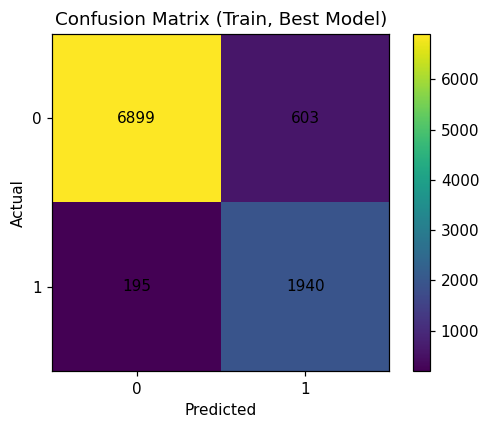

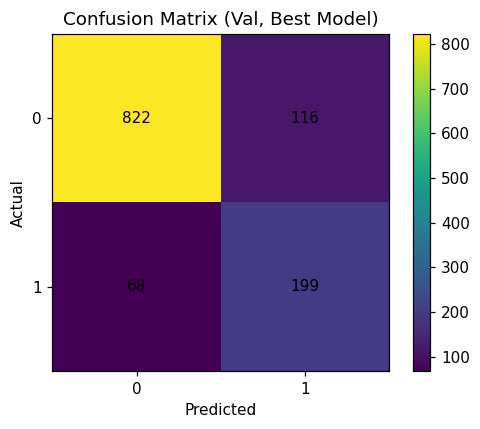

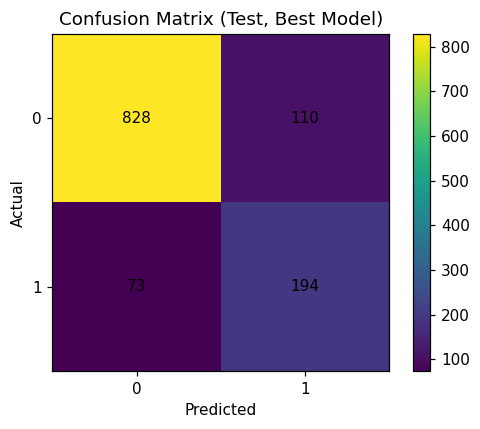

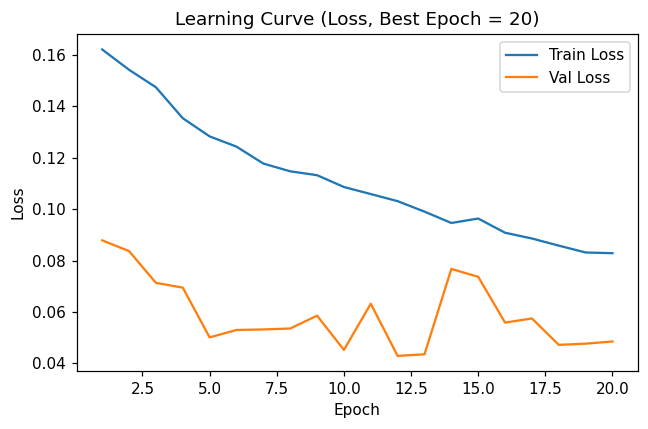

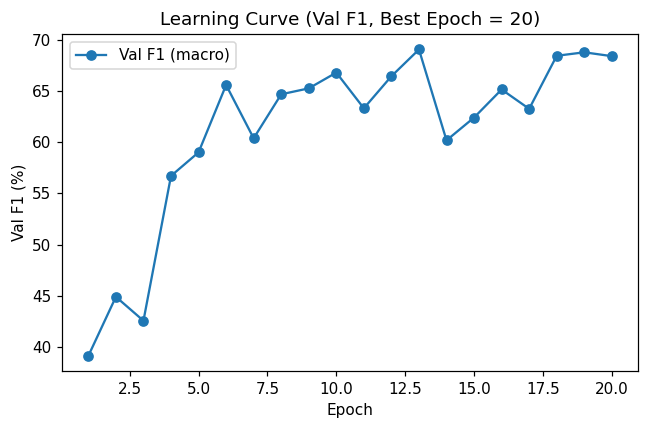

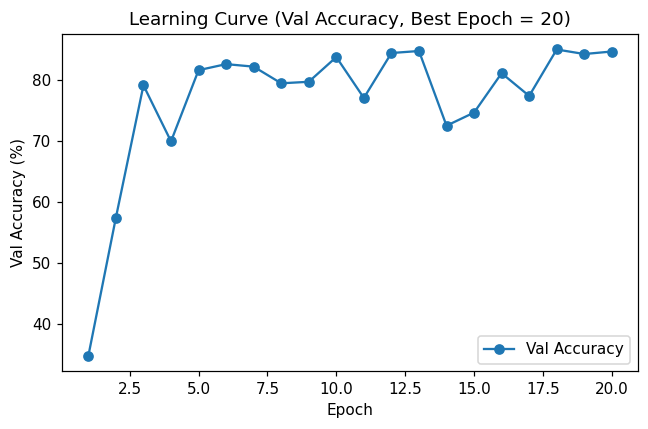

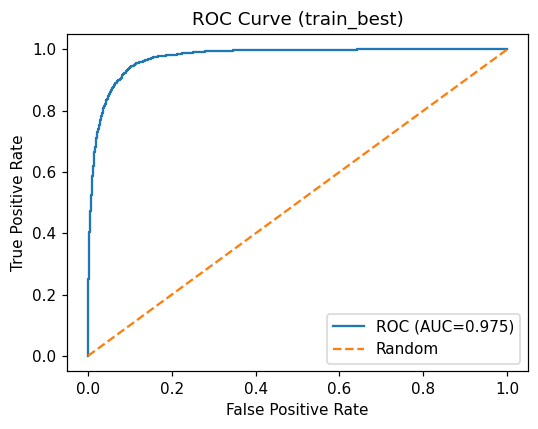

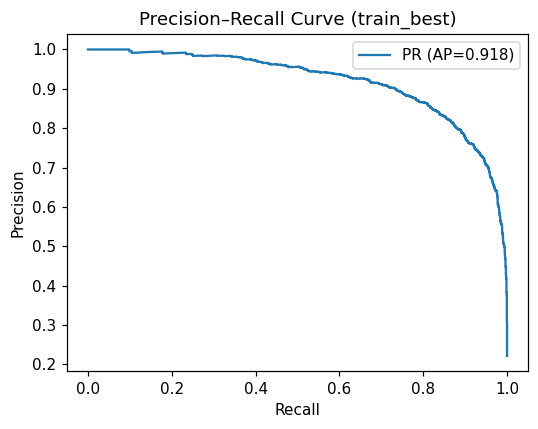

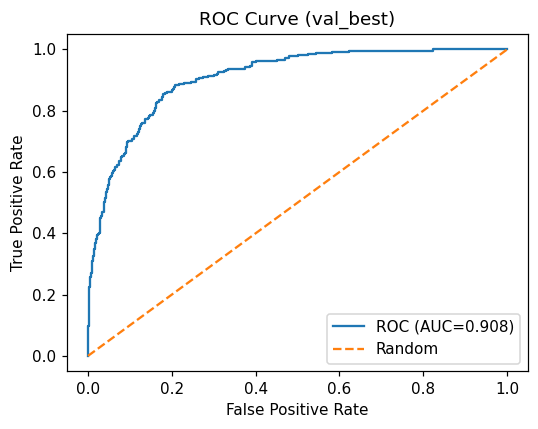

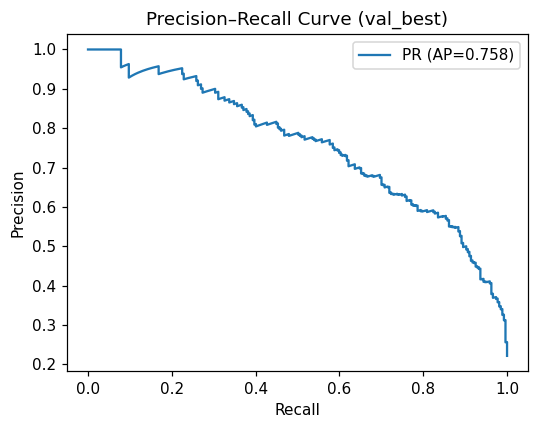

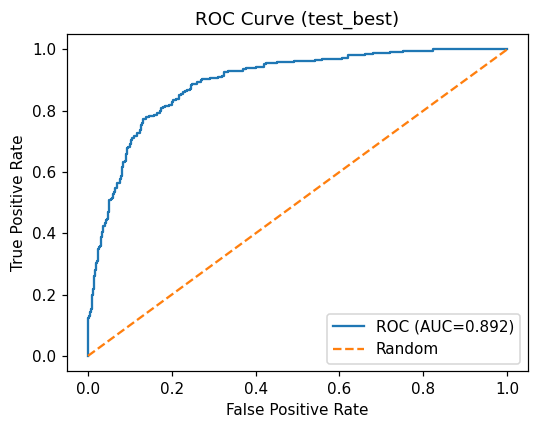

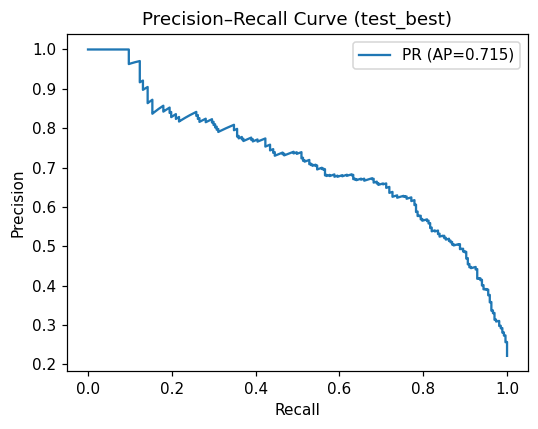

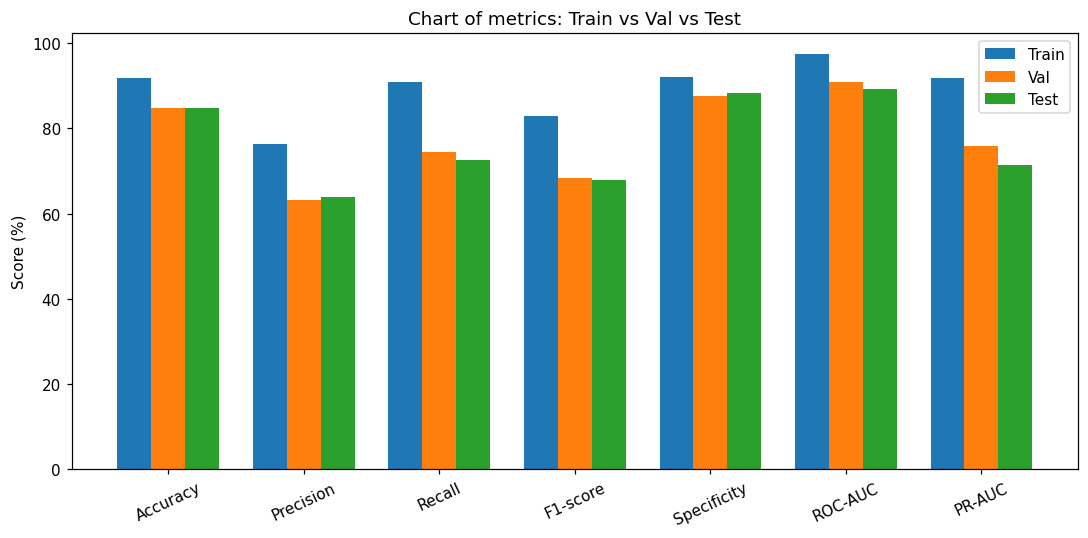

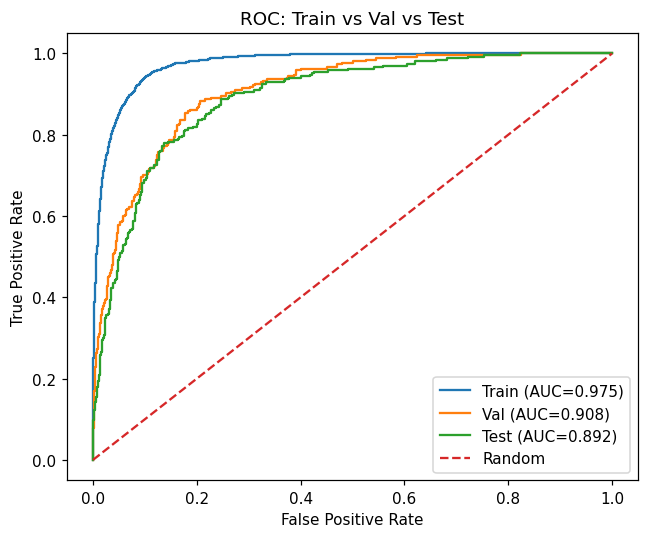

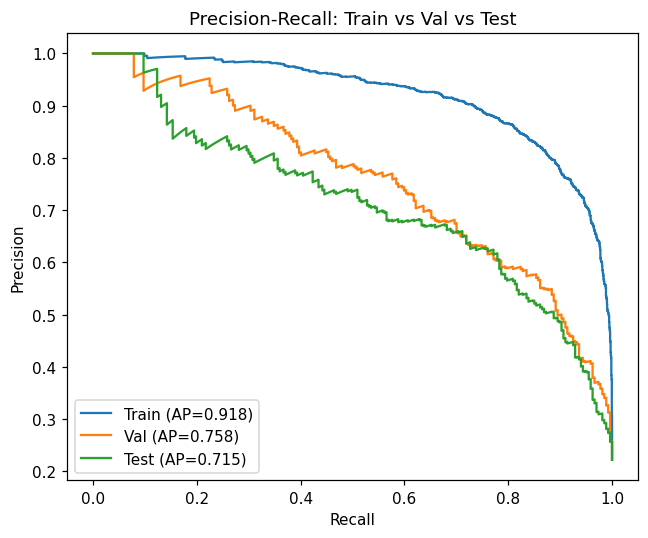

In [24]:
train_metrics_best, ytr_best, ptr_best, str_best = evaluate(model, dl_train_eval, device)
val_metrics_best,   yv_best,  pv_best,  sv_best  = evaluate(model, dl_val,        device)
test_metrics_best,  yt_best,  pt_best,  st_best  = evaluate(model, dl_test,       device)

train_pct = {k: round(v * 100, 3) for k, v in train_metrics_best.items()}
val_pct   = {k: round(v * 100, 3) for k, v in val_metrics_best.items()}
test_pct  = {k: round(v * 100, 3) for k, v in test_metrics_best.items()}

print("\n[Best model @ Train]")
print("Accuracy (%)        :", train_pct["acc"])
print("Precision (%)       :", train_pct["prec"])
print("Recall (%)          :", train_pct["rec"])
print("F1-Score (%)        :", train_pct["f1"])
print("Specificity (%)     :", train_pct["spec"])
print("ROC-AUC (%)         :", train_pct["roc_auc"])
print("Precision-recall (%):", train_pct["pr_auc"])

print("\n[Best model @ Val]")
print("Accuracy (%)        :", val_pct["acc"])
print("Precision (%)       :", val_pct["prec"])
print("Recall (%)          :", val_pct["rec"])
print("F1-Score (%)        :", val_pct["f1"])
print("Specificity (%)     :", val_pct["spec"])
print("ROC-AUC (%)         :", val_pct["roc_auc"])
print("Precision-recall (%):", val_pct["pr_auc"])

print("\n[Best model @ Test]")
print("Accuracy (%)        :", test_pct["acc"])
print("Precision (%)       :", test_pct["prec"])
print("Recall (%)          :", test_pct["rec"])
print("F1-Score (%)        :", test_pct["f1"])
print("Specificity (%)     :", test_pct["spec"])
print("ROC-AUC (%)         :", test_pct["roc_auc"])
print("Precision-recall (%):", test_pct["pr_auc"])

# confusion matrix
plot_confusion_matrix(
    ytr_best, ptr_best,
    out_path=os.path.join(OUT_DIR, "confmat_train_best.png"),
    title="Confusion Matrix (Train, Best Model)"
)

plot_confusion_matrix(
    yv_best, pv_best,
    out_path=os.path.join(OUT_DIR, "confmat_val_best.png"),
    title="Confusion Matrix (Val, Best Model)"
)

plot_confusion_matrix(
    yt_best, pt_best,
    out_path=os.path.join(OUT_DIR, "confmat_test_best.png"),
    title="Confusion Matrix (Test, Best Model)"
)

# learning curves
plot_learning_curves(
    history=history,
    best_epoch=best_epoch,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_accuracy_curve(
    history=history,
    best_epoch=best_epoch,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

# roc/pr curves
plot_roc_pr(
    y_true=ytr_best,
    y_score=str_best,
    out_dir=OUT_DIR,
    prefix="train_best",
    roc_auc=train_metrics_best["roc_auc"],
    pr_auc=train_metrics_best["pr_auc"]
)

plot_roc_pr(
    y_true=yv_best,
    y_score=sv_best,
    out_dir=OUT_DIR,
    prefix="val_best",
    roc_auc=val_metrics_best["roc_auc"],
    pr_auc=val_metrics_best["pr_auc"]
)

plot_roc_pr(
    y_true=yt_best,
    y_score=st_best,
    out_dir=OUT_DIR,
    prefix="test_best",
    roc_auc=test_metrics_best["roc_auc"],
    pr_auc=test_metrics_best["pr_auc"]
)

plot_split_metrics_bar(
    train_metrics=train_metrics_best,
    val_metrics=val_metrics_best,
    test_metrics=test_metrics_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_roc_compare_splits(
    y_train=ytr_best, s_train=str_best,
    y_val=yv_best,    s_val=sv_best,
    y_test=yt_best,   s_test=st_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)

plot_pr_compare_splits(
    y_train=ytr_best, s_train=str_best,
    y_val=yv_best,    s_val=sv_best,
    y_test=yt_best,   s_test=st_best,
    out_dir=OUT_DIR,
    prefix="convnextv2_tiny_focal"
)


In [25]:
def compute_dice_iou(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6):
    preds_f   = preds.view(preds.size(0), -1)
    targets_f = targets.view(targets.size(0), -1)

    inter = (preds_f * targets_f).sum(dim=1)
    union = preds_f.sum(dim=1) + targets_f.sum(dim=1)

    dice = (2.0 * inter + eps) / (union + eps)

    iou_den = (preds_f + targets_f - preds_f * targets_f).sum(dim=1)
    iou = (inter + eps) / (iou_den + eps)

    return dice, iou


def denormalize(img_tensor: torch.Tensor):
    img = img_tensor.detach().cpu().clone()
    img = img * 0.25 + 0.5   # x * std + mean
    img = img.clamp(0.0, 1.0)
    return img.squeeze(0).numpy()

@torch.no_grad()
def visualize_localization_examples(
    model,
    loader,
    device,
    threshold: float = 0.5,
    num_pos: int = 2,
    num_neg: int = 2,
    num_hard: int = 2,
    save_dir: str = None,
    prefix: str = "loc_example",
):
    model.eval()
    pos_shown = neg_shown = hard_shown = 0
    example_idx = 0

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    for xb, yb, mb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        mb = mb.to(device, non_blocking=True)

        cls_logits, loc_logits = model(xb)

        cls_prob = torch.sigmoid(cls_logits)  # [B]
        # heatmap upsample to image size for visualization + dice
        heat = torch.sigmoid(loc_logits)      # [B,1,h,w]
        heat_up = F.interpolate(heat, size=mb.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = (heat_up >= threshold).float()

        dice_batch, iou_batch = compute_dice_iou(pred_mask, mb)

        for i in range(xb.size(0)):
            label = int(yb[i].item())
            p = float(cls_prob[i].item())
            dice_val = float(dice_batch[i].cpu().item())
            iou_val  = float(iou_batch[i].cpu().item())

            category = None
            title_suffix = ""

            is_wrong = ((p >= 0.5) != (label == 1))
            near_th  = (abs(p - 0.5) <= 0.05)

            if label == 1 and pos_shown < num_pos:
                category = "pos"
                title_suffix = f"Positive (p={p:.2f}, Dice={dice_val:.2f}, IoU={iou_val:.2f})"
                pos_shown += 1
            elif label == 0 and neg_shown < num_neg:
                category = "neg"
                title_suffix = f"Negative (p={p:.2f}, Dice={dice_val:.2f}, IoU={iou_val:.2f})"
                neg_shown += 1
            elif hard_shown < num_hard and (is_wrong or near_th or (label==1 and dice_val < 0.3)):
                category = "hard"
                title_suffix = f"Hard (y={label}, p={p:.2f}, Dice={dice_val:.2f}, IoU={iou_val:.2f})"
                hard_shown += 1

            if category is None:
                continue

            img_np  = denormalize(xb[i])
            gt_np   = mb[i].detach().cpu().squeeze(0).numpy()
            heat_np = heat_up[i].detach().cpu().squeeze(0).numpy()

            import matplotlib.pyplot as plt
            plt.figure(figsize=(12,4))
            plt.subplot(1,3,1); plt.title("Image"); plt.imshow(img_np, cmap="gray"); plt.axis("off")
            plt.subplot(1,3,2); plt.title("GT Mask"); plt.imshow(gt_np, cmap="gray"); plt.axis("off")
            plt.subplot(1,3,3); plt.title("Heatmap"); plt.imshow(img_np, cmap="gray"); 
            plt.imshow(heat_np, alpha=0.5); plt.axis("off")
            plt.suptitle(title_suffix)

            if save_dir is not None:
                out_path = os.path.join(save_dir, f"{prefix}_{category}_{example_idx:03d}.png")
                plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.show()
            plt.close()

            example_idx += 1

            if pos_shown >= num_pos and neg_shown >= num_neg and hard_shown >= num_hard:
                return


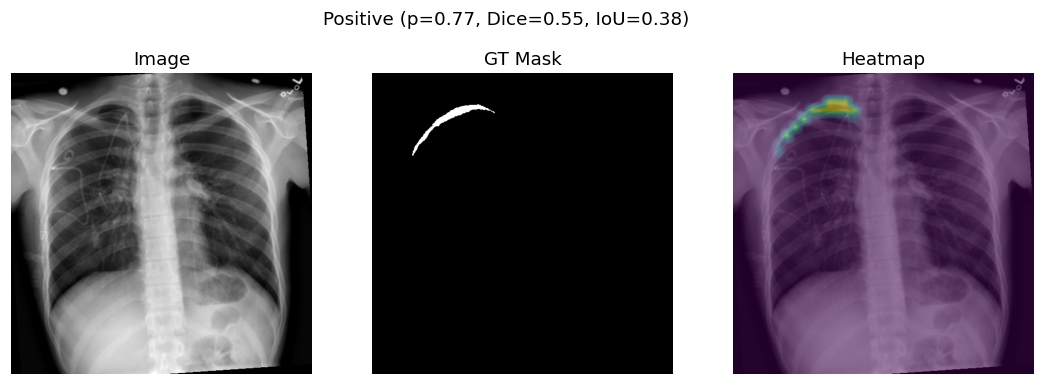

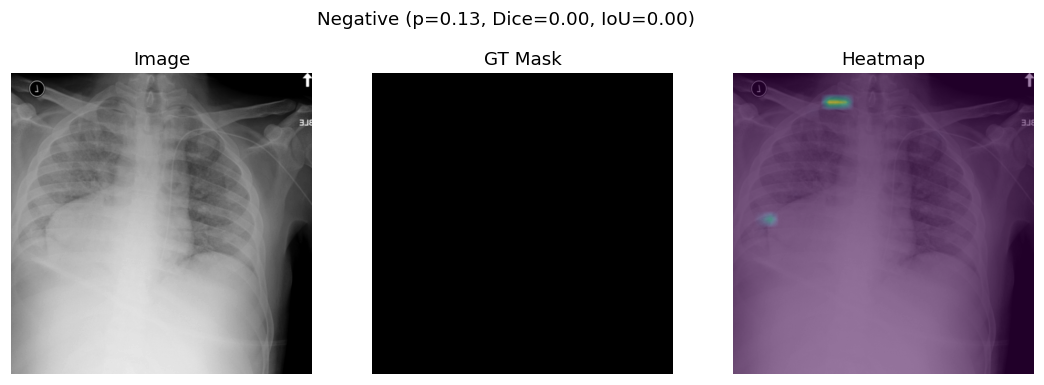

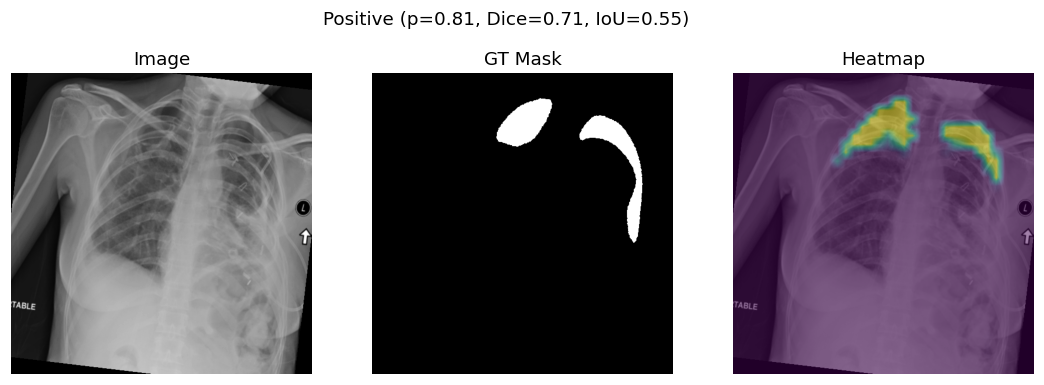

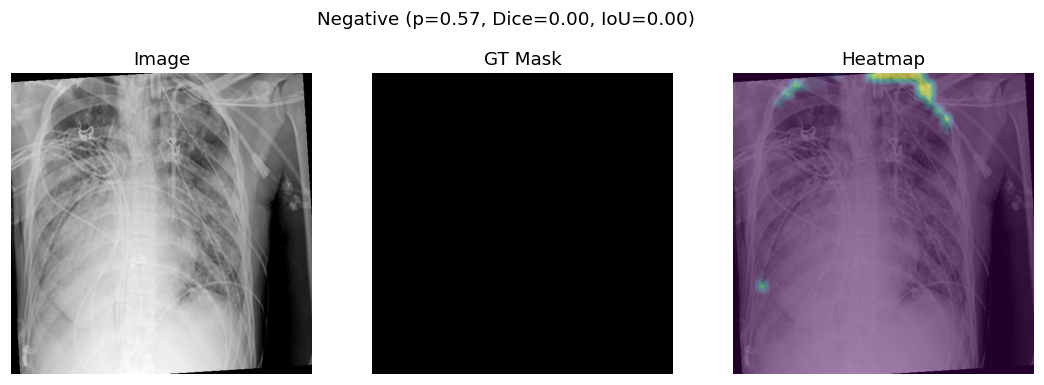

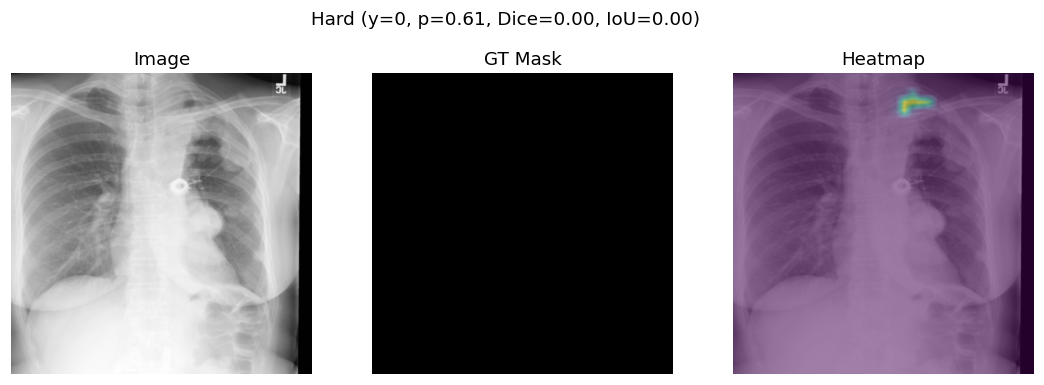

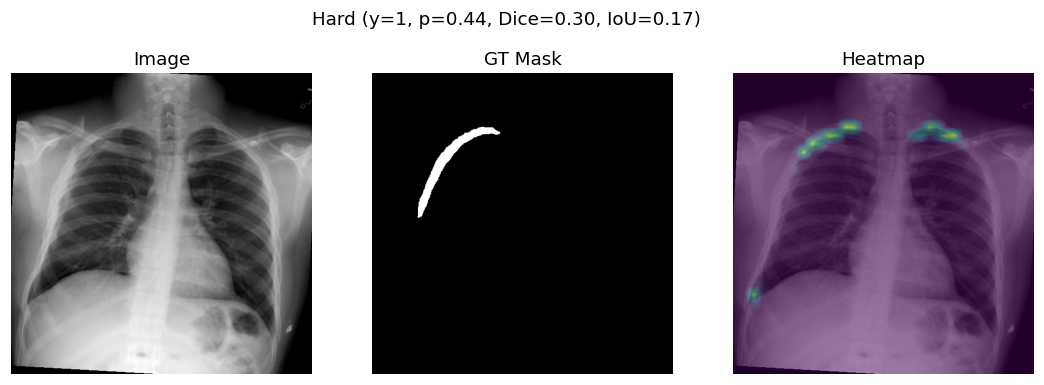

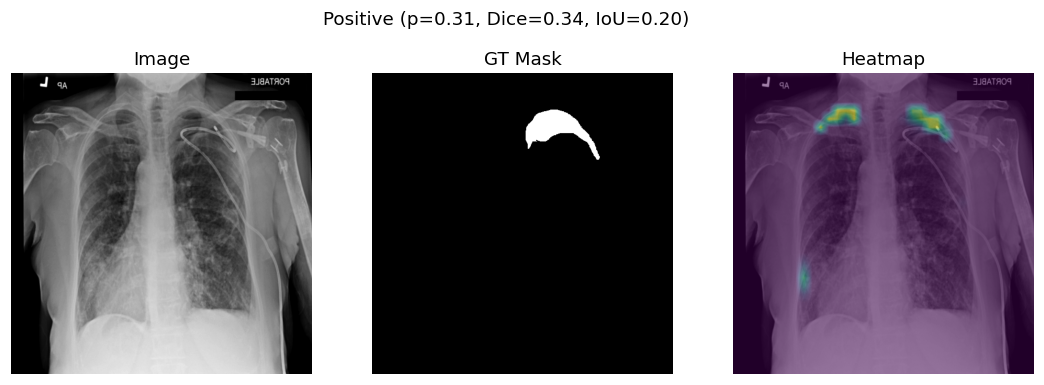

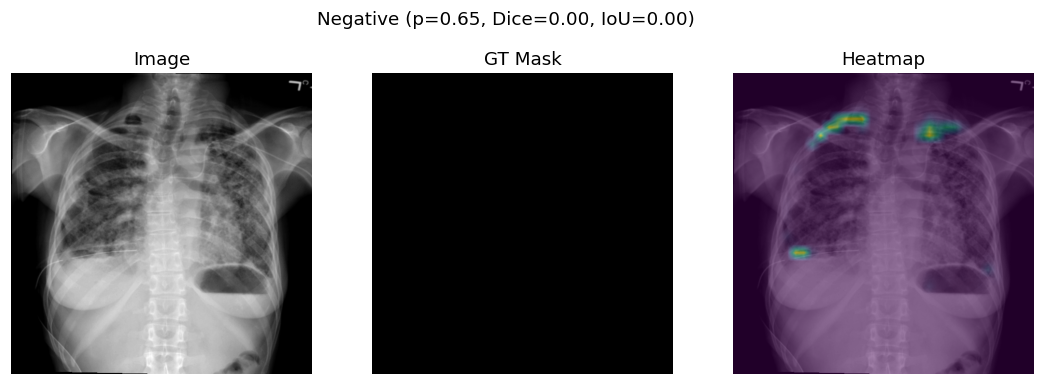

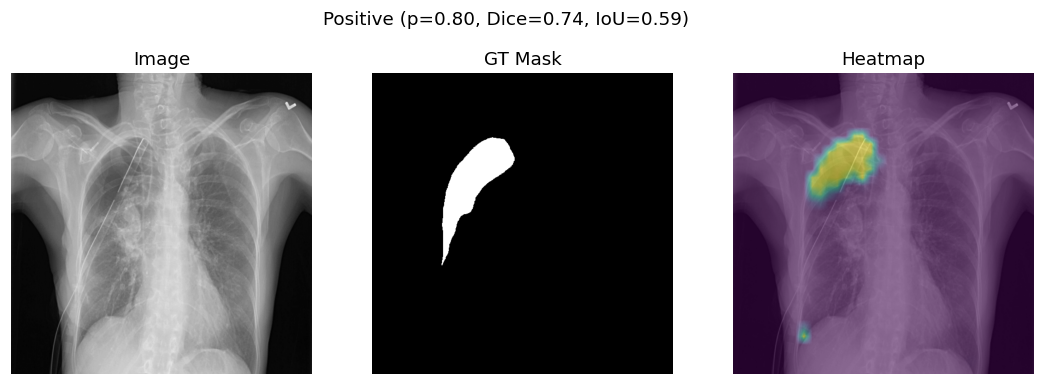

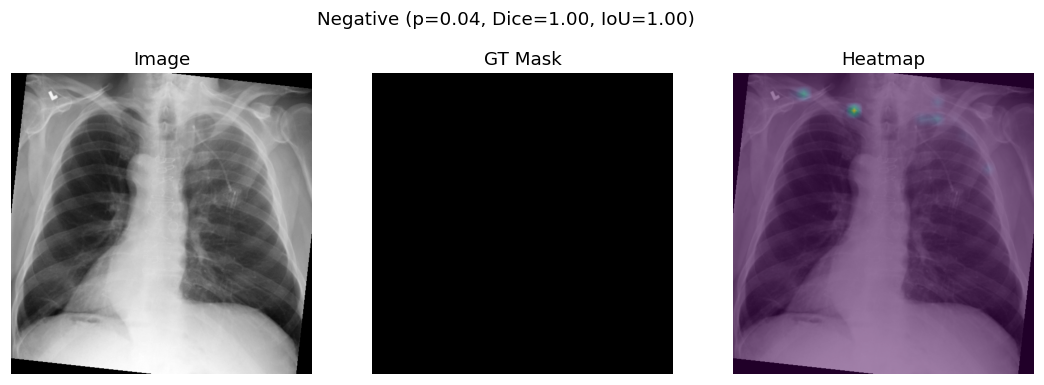

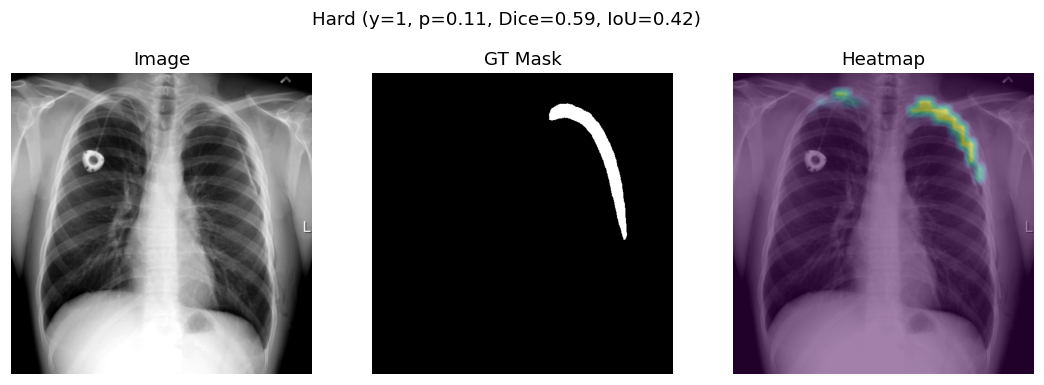

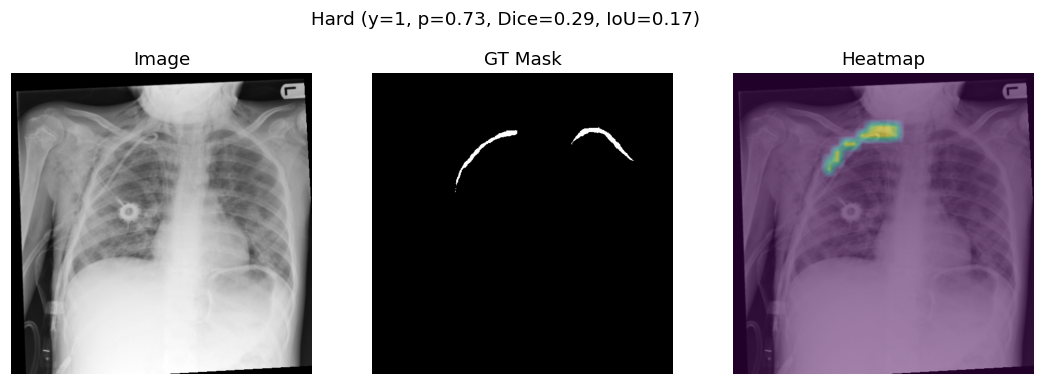

In [26]:
visualize_localization_examples(
    model=model,
    loader=dl_train,
    device=device,
    threshold=0.5,
    num_pos=2,
    num_neg=2,
    num_hard=2,
    save_dir=OUT_DIR,
    prefix="loc_train_examples"
)

eval_mask_tfms = JointImageMaskTransform(out_size=IMG_SIZE)
ds_test_seg = PandasImageMaskDataset(test_df, mask_root=MASK_ROOT, joint_transform=eval_mask_tfms)
dl_test_seg = DataLoader(ds_test_seg, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

visualize_localization_examples(
    model=model,
    loader=dl_test_seg,
    device=device,
    threshold=0.5,
    num_pos=2,
    num_neg=2,
    num_hard=2,
    save_dir=OUT_DIR,
    prefix="loc_test_examples"
)



=== Top 10 thresholds on val (sorted by f1) ===
threshold    acc   prec    rec     f1   spec
    0.428 83.402 58.981 82.397 68.750 83.689
    0.480 84.315 61.747 76.779 68.447 86.461
    0.376 82.407 56.824 85.768 68.358 81.450
    0.532 85.228 65.398 70.787 67.986 89.339
    0.584 85.726 68.482 65.918 67.176 91.365
    0.323 80.083 53.020 88.764 66.387 77.612
    0.637 86.722 76.098 58.427 66.102 94.776
    0.271 76.680 48.594 90.637 63.268 72.708
    0.219 73.029 44.765 92.884 60.414 67.377
    0.689 85.560 81.208 45.318 58.173 97.015

Best threshold on validation set (by f1):
t = 0.428, Acc=83.402%, Prec=58.981%, Rec=82.397%, F1=68.750%, Spec=83.689%


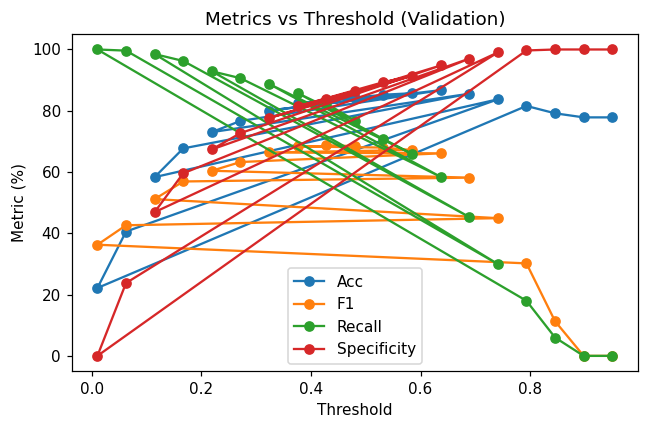


>>> The best threshold on validation set: best_t = 0.428

[Best threshold model @ Test (t=0.428)]
Accuracy (%)        : 83.817
Precision (%)       : 60.405
Recall (%)          : 78.277
F1-Score (%)        : 68.189
Specificity (%)     : 85.394
ROC-AUC (%)         : 89.222
Precision-recall (%): 71.509

[Best threshold model @ Val (t=0.428)]
Accuracy (%)        : 83.402
Precision (%)       : 58.981
Recall (%)          : 82.397
F1-Score (%)        : 68.750


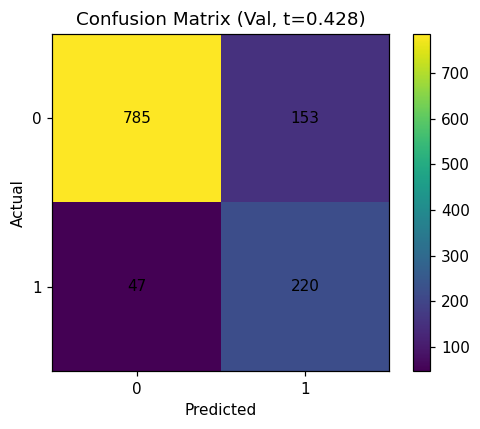

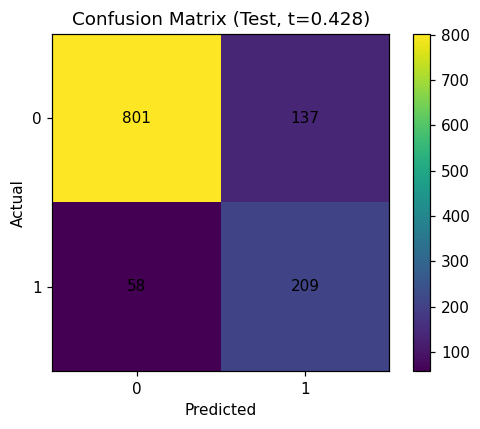

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score
)

def sweep_thresholds(y_true, y_score, thresholds=None, sort_by="f1", verbose=True):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_score = np.asarray(y_score).ravel()

    if thresholds is None:
        thresholds = np.linspace(0.01, 0.95, 19)

    results = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp + 1e-8)
        else:
            spec = float("nan")

        results.append({
            "threshold": t,
            "acc": acc,
            "prec": prec,
            "rec": rec,
            "f1": f1,
            "spec": spec,
        })

    df_thr = pd.DataFrame(results)
    df_thr_sorted = df_thr.sort_values(sort_by, ascending=False).reset_index(drop=True)

    if verbose:
        print(f"\n=== Top 10 thresholds on val (sorted by {sort_by}) ===")
        tmp = df_thr_sorted.copy()
        for col in ["acc", "prec", "rec", "f1", "spec"]:
            tmp[col] = tmp[col] * 100.0
        print(tmp.head(10).to_string(index=False, 
                                     formatters={"threshold": "{:.3f}".format,
                                                 "acc": "{:.3f}".format,
                                                 "prec": "{:.3f}".format,
                                                 "rec": "{:.3f}".format,
                                                 "f1": "{:.3f}".format,
                                                 "spec": "{:.3f}".format}))

        best_row = df_thr_sorted.iloc[0]
        print("\nBest threshold on validation set (by {}):".format(sort_by))
        print(
            f"t = {best_row['threshold']:.3f}, "
            f"Acc={best_row['acc']*100:.3f}%, "
            f"Prec={best_row['prec']*100:.3f}%, "
            f"Rec={best_row['rec']*100:.3f}%, "
            f"F1={best_row['f1']*100:.3f}%, "
            f"Spec={best_row['spec']*100:.3f}%"
        )

    return df_thr_sorted

def plot_threshold_metrics(df_thr, out_dir, prefix="val_thr"):
    os.makedirs(out_dir, exist_ok=True)

    thr = df_thr["threshold"].values

    plt.figure(figsize=(6,4))
    for key, label in [
        ("acc",  "Acc"),
        ("f1",   "F1"),
        ("rec",  "Recall"),
        ("spec", "Specificity"),
    ]:
        if key in df_thr.columns:
            plt.plot(thr, df_thr[key].values * 100.0, marker="o", label=label)

    plt.xlabel("Threshold")
    plt.ylabel("Metric (%)")
    plt.title("Metrics vs Threshold (Validation)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{prefix}_metrics_vs_threshold.png"), dpi=300)
    plt.show()


df_thr_val = sweep_thresholds(yv_best, sv_best, sort_by="f1", verbose=True)
plot_threshold_metrics(df_thr_val, OUT_DIR, prefix="val_thr")

best_t = df_thr_val.iloc[0]["threshold"]
print(f"\n>>> The best threshold on validation set: best_t = {best_t:.3f}")

yt = np.asarray(yt_best).astype(int).ravel()
st = np.asarray(st_best).ravel()

y_test_pred = (st >= best_t).astype(int)

test_acc  = accuracy_score(yt, y_test_pred)
test_prec = precision_score(yt, y_test_pred, zero_division=0)
test_rec  = recall_score(yt, y_test_pred, zero_division=0)
test_f1   = f1_score(yt, y_test_pred, zero_division=0)

cm_test = confusion_matrix(yt, y_test_pred)
if cm_test.shape == (2, 2):
    tn, fp, fn, tp = cm_test.ravel()
    test_spec = tn / (tn + fp + 1e-8)
else:
    test_spec = float("nan")

test_roc = roc_auc_score(yt, st)
test_pr  = average_precision_score(yt, st)

print(f"\n[Best threshold model @ Test (t={best_t:.3f})]")
print(f"Accuracy (%)        : {test_acc*100:.3f}")
print(f"Precision (%)       : {test_prec*100:.3f}")
print(f"Recall (%)          : {test_rec*100:.3f}")
print(f"F1-Score (%)        : {test_f1*100:.3f}")
print(f"Specificity (%)     : {test_spec*100:.3f}")
print(f"ROC-AUC (%)         : {test_roc*100:.3f}")
print(f"Precision-recall (%): {test_pr*100:.3f}")

y_val_pred = (np.asarray(sv_best) >= best_t).astype(int)
val_acc2  = accuracy_score(yv_best, y_val_pred)
val_prec2 = precision_score(yv_best, y_val_pred, zero_division=0)
val_rec2  = recall_score(yv_best, y_val_pred, zero_division=0)
val_f12   = f1_score(yv_best, y_val_pred, zero_division=0)

print(f"\n[Best threshold model @ Val (t={best_t:.3f})]")
print(f"Accuracy (%)        : {val_acc2*100:.3f}")
print(f"Precision (%)       : {val_prec2*100:.3f}")
print(f"Recall (%)          : {val_rec2*100:.3f}")
print(f"F1-Score (%)        : {val_f12*100:.3f}")

# --- Confusion matrix at best threshold ---

# Val
plot_confusion_matrix(
    y_true=yv_best,
    y_pred=y_val_pred,
    out_path=os.path.join(OUT_DIR, f"confmat_val_best_t_{best_t:.3f}.png"),
    title=f"Confusion Matrix (Val, t={best_t:.3f})"
)

# Test
plot_confusion_matrix(
    y_true=yt,
    y_pred=y_test_pred,
    out_path=os.path.join(OUT_DIR, f"confmat_test_best_t_{best_t:.3f}.png"),
    title=f"Confusion Matrix (Test, t={best_t:.3f})"
)

In [28]:
import pandas as pd

rows = [
    {
        "Split": "Train (Best)",
        "Accuracy (%)":         train_pct["acc"],
        "Precision (%)":        train_pct["prec"],
        "Recall (%)":           train_pct["rec"],
        "F1-Score (%)":         train_pct["f1"],
        "Specificity (%)":      train_pct["spec"],
        "ROC-AUC (%)":          train_pct["roc_auc"],
        "Precision-recall (%)": train_pct["pr_auc"],
    },
    {
        "Split": "Val (Best)",
        "Accuracy (%)":         val_pct["acc"],
        "Precision (%)":        val_pct["prec"],
        "Recall (%)":           val_pct["rec"],
        "F1-Score (%)":         val_pct["f1"],
        "Specificity (%)":      val_pct["spec"],
        "ROC-AUC (%)":          val_pct["roc_auc"],
        "Precision-recall (%)": val_pct["pr_auc"],
    },
    {
        "Split": "Test (Best)",
        "Accuracy (%)":         test_pct["acc"],
        "Precision (%)":        test_pct["prec"],
        "Recall (%)":           test_pct["rec"],
        "F1-Score (%)":         test_pct["f1"],
        "Specificity (%)":      test_pct["spec"],
        "ROC-AUC (%)":          test_pct["roc_auc"],
        "Precision-recall (%)": test_pct["pr_auc"],
    },
]

df_best = pd.DataFrame(rows)
print(df_best)

df_best.to_csv(os.path.join(OUT_DIR, "best_train_val_test_metrics_convnextv2.csv"), index=False, mode="w")


          Split  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  \
0  Train (Best)        91.719         76.288      90.867        82.941   
1    Val (Best)        84.730         63.175      74.532        68.385   
2   Test (Best)        84.813         63.816      72.659        67.951   

   Specificity (%)  ROC-AUC (%)  Precision-recall (%)  
0           91.962       97.468                91.831  
1           87.633       90.806                75.826  
2           88.273       89.222                71.509  
